# Project Title: Quality Prediction in Mining Process using Machine Learning

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/MiningProcess_Flotation_Plant_Database.csv')
df.head()

,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,2017-03-10 01:00:00,"55,2","16,98","3019,53","557,434","395,713","10,0664","1,74","249,214","253,235",...,"250,884","457,396","432,962","424,954","443,558","502,255","446,37","523,344","66,91","1,31"
1,2017-03-10 01:00:00,"55,2","16,98","3024,41","563,965","397,383","10,0672","1,74","249,719","250,532",...,"248,994","451,891","429,56","432,939","448,086","496,363","445,922","498,075","66,91","1,31"
2,2017-03-10 01:00:00,"55,2","16,98","3043,46","568,054","399,668","10,068","1,74","249,741","247,874",...,"248,071","451,24","468,927","434,61","449,688","484,411","447,826","458,567","66,91","1,31"
3,2017-03-10 01:00:00,"55,2","16,98","3047,36","568,665","397,939","10,0689","1,74","249,917","254,487",...,"251,147","452,441","458,165","442,865","446,21","471,411","437,69","427,669","66,91","1,31"
4,2017-03-10 01:00:00,"55,2","16,98","3033,69","558,167","400,254","10,0697","1,74","250,203","252,136",...,"248,928","452,441","452,9","450,523","453,67","462,598","443,682","425,679","66,91","1,31"


In [ ]:
for col in df.columns:
    if col != 'date':
        df[col] = df[col].astype(str).str.replace(',', '.').astype(float)

In [ ]:
df['date'] = pd.to_datetime(df['date'])

In [ ]:
df = df.sort_values(by='date')
df = df.drop_duplicates()

In [ ]:
df.isnull().sum()

,0
date,0
% Iron Feed,0
% Silica Feed,0
Starch Flow,0
Amina Flow,0
Ore Pulp Flow,0
Ore Pulp pH,0
Ore Pulp Density,0
Flotation Column 01 Air Flow,0
Flotation Column 02 Air Flow,0


In [ ]:
df.describe()

,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
count,736282,736282.000000,736282.000000,736282.000000,736282.000000,736282.000000,736282.000000,736282.000000,736282.000000,736282.000000,...,736282.000000,736282.000000,736282.000000,736282.000000,736282.000000,736282.00000,736282.000000,736282.000000,736282.000000,736282.000000
mean,2017-06-16 02:30:44.009767936,56.298307,14.648984,2869.636615,488.165523,397.570736,9.767315,1.680424,280.119813,277.121249,...,290.740507,520.168402,522.555279,531.283790,420.169753,425.09453,429.889517,420.910258,65.049096,2.327270
min,2017-03-10 01:00:00,42.740000,1.310000,0.002026,241.669000,376.249000,8.753340,1.519820,175.510000,175.156000,...,185.962000,149.218000,210.752000,126.255000,162.201000,166.99100,155.841000,175.349000,62.050000,0.600000
25%,2017-05-04 21:00:00,52.670000,8.940000,2075.070000,431.835848,394.248000,9.527050,1.647390,250.278000,250.448000,...,256.047750,416.902000,441.835250,411.256000,356.627000,357.59525,358.438000,356.705250,64.370000,1.440000
50%,2017-06-16 12:00:00,56.080000,13.850000,3020.230000,504.352500,399.238000,9.797460,1.697580,299.341000,296.202000,...,299.002000,491.749000,495.853500,494.184000,411.770500,408.65000,424.427000,410.940000,65.210000,2.000000
75%,2017-07-29 09:00:00,59.720000,19.600000,3728.930000,553.335750,402.967000,10.037800,1.728380,300.147000,300.686000,...,301.907000,594.097750,595.293000,601.299000,485.285000,484.00800,492.773000,476.145000,65.860000,3.010000
max,2017-09-09 23:00:00,65.780000,33.400000,6300.230000,739.538000,418.641000,10.808100,1.853250,373.871000,375.992000,...,371.593000,862.274000,828.919000,886.822000,680.359000,675.64400,698.861000,659.902000,68.010000,5.530000
std,NaN,5.160365,6.810741,1216.017896,91.254428,9.705444,0.387176,0.069206,29.633831,30.157126,...,28.690520,131.085819,128.216232,150.931865,91.755819,84.47917,89.919586,84.899167,1.118721,1.125616


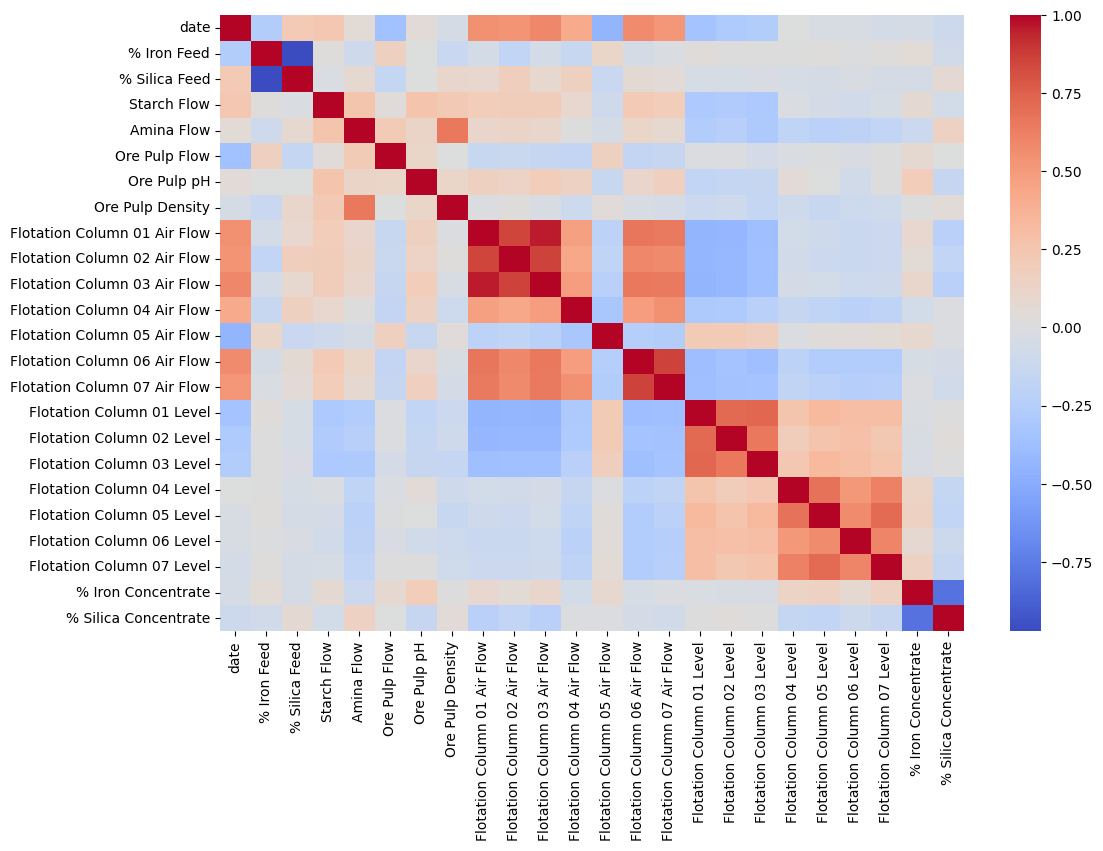

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

In [ ]:
corr = df.corr()['% Silica Concentrate'].sort_values(ascending=False)
print(corr.head(10))

% Silica Concentrate            1.000000
Amina Flow                      0.156981
% Silica Feed                   0.072676
Ore Pulp Density                0.047002
Flotation Column 02 Level       0.031790
Flotation Column 01 Level       0.017859
Flotation Column 03 Level       0.014843
Ore Pulp Flow                   0.008497
Flotation Column 04 Air Flow   -0.004770
Flotation Column 05 Air Flow   -0.008930
Name: % Silica Concentrate, dtype: float64


In [ ]:
df['silica_lag_1'] = df['% Silica Concentrate'].shift(1)
df['silica_lag_2'] = df['% Silica Concentrate'].shift(2)
df['silica_lag_3'] = df['% Silica Concentrate'].shift(3)

In [ ]:
df['silica_future_1'] = df['% Silica Concentrate'].shift(-1)
df['silica_future_2'] = df['% Silica Concentrate'].shift(-2)

In [ ]:
df = df.dropna()

In [ ]:
X = df.drop(columns=['% Silica Concentrate', 'date'])
y = df['% Silica Concentrate']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse_with_iron = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE (with iron):", rmse_with_iron)

RMSE (with iron): 0.032996978982866895


In [ ]:
X_no_iron = df.drop(columns=['% Silica Concentrate', 'date', '% Iron Concentrate'])
y = df['% Silica Concentrate']

X_train, X_test, y_train, y_test = train_test_split(
    X_no_iron, y, test_size=0.2, random_state=42
)

model = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse_without_iron = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE (without iron):", rmse_without_iron)

RMSE (without iron): 0.05043021592181939


In [ ]:
import pickle

with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)

In [ ]:
with open('model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

sample = X_test.iloc[0:1]
prediction = loaded_model.predict(sample)

print("Prediction:", prediction)

Prediction: [4.907086]


In [ ]:
print("Final Results:")
print("RMSE (with iron):", rmse_with_iron)
print("RMSE (without iron):", rmse_without_iron)

Final Results:
RMSE (with iron): 0.032996978982866895
RMSE (without iron): 0.05043021592181939


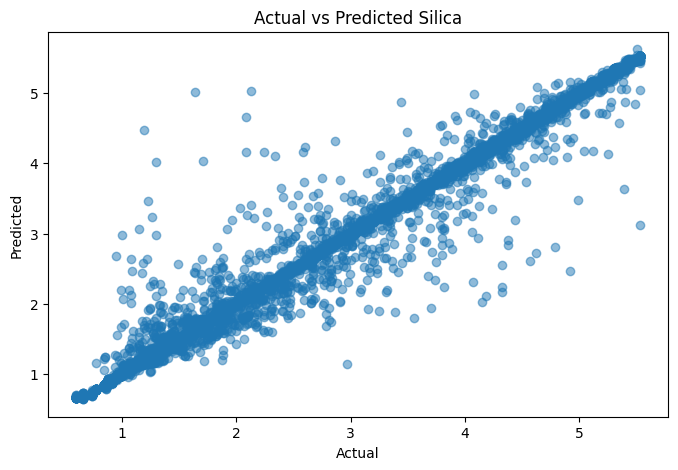

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Silica")
plt.show()

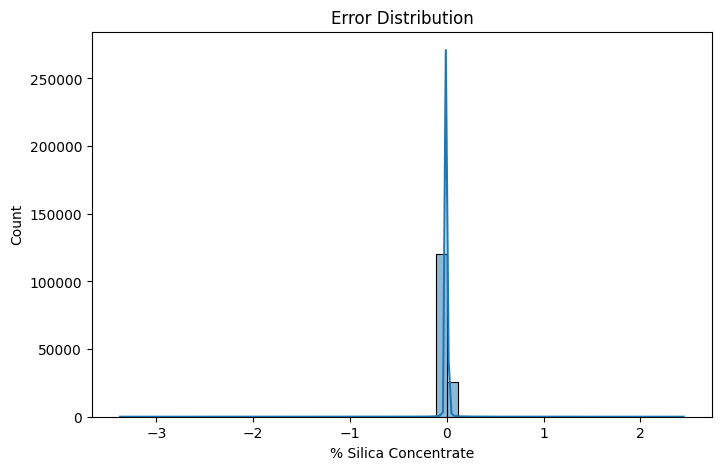

In [ ]:
errors = y_test - y_pred

plt.figure(figsize=(8,5))
sns.histplot(errors, bins=50, kde=True)
plt.title("Error Distribution")
plt.show()

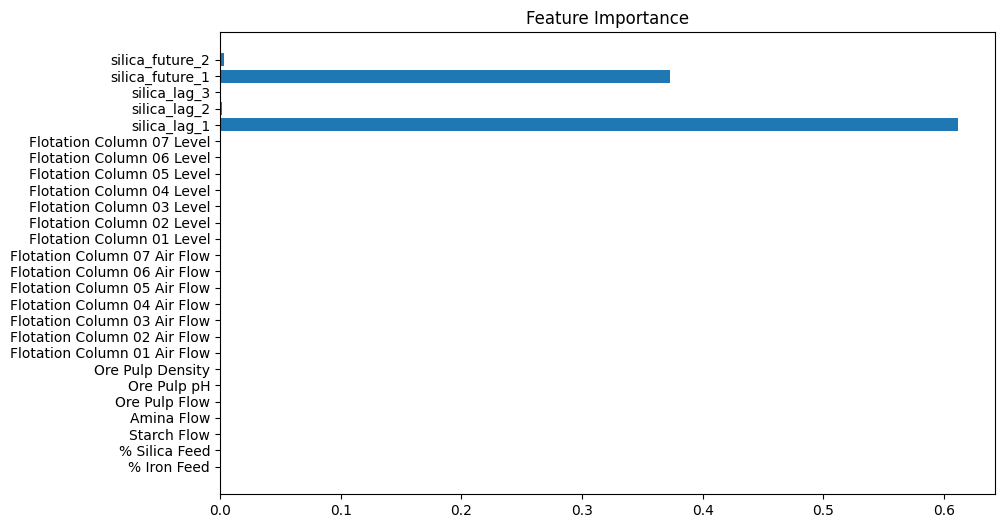

In [ ]:
import matplotlib.pyplot as plt

importance = model.feature_importances_
features = X_no_iron.columns

plt.figure(figsize=(10,6))
plt.barh(features, importance)
plt.title("Feature Importance")
plt.show()